# Лабораторная работа №3
### 6132 Казаков Павел
### Вариант 7

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Callable

## 1. Создать средствами OpenCV бинарное изображение с простым рисунком

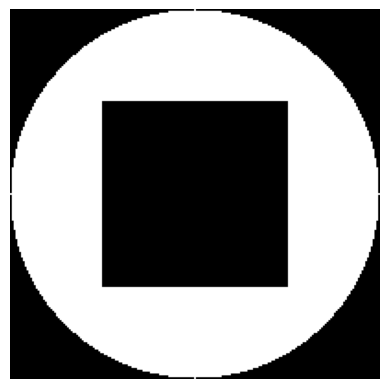

In [2]:
img = np.zeros((201, 201), dtype=np.uint8)
cv2.circle(img, (100, 100), 100, 1, -1)
cv2.rectangle(img, (50, 50), (150, 150), 0, -1)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

## 2. Зашумить изображение импульсным шумом с вероятностью p 

In [3]:
def add_noise(x:np.ndarray, p:float) -> np.ndarray:
    noise_x = x.copy()
    rand = np.random.rand(*x.shape)
    noise_x[rand < p] = 1 - noise_x[rand < p]
    return noise_x

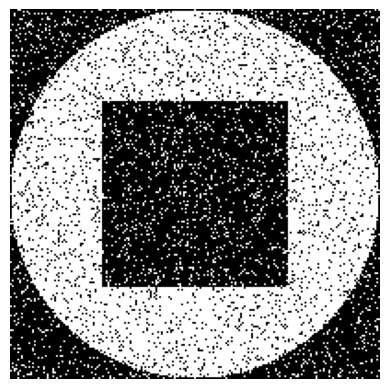

Империческая вероятность шума: 0.09975000618796565


In [4]:
noise_img = add_noise(img, p=0.1)

plt.imshow(noise_img, cmap="gray")
plt.axis("off")
plt.show()

print(f"Империческая вероятность шума: {np.sum(noise_img-img != 0) / (img.size)}")

## 3. Написать функции реализации эрозии и дилатации

In [5]:
def slide(x:np.ndarray, y:np.ndarray, 
         core:Callable[[np.ndarray, np.ndarray], int],
         pad_value:int=0) -> np.ndarray:
    M, N = x.shape

    top, left = (int(y.shape[0] % 2 == 0), int(y.shape[1] % 2 == 0))
    y = np.pad(y, ((0, top),(0, left)))

    top, left = np.array(y.shape) // 2
    x = np.pad(x, ((top, top),(left, left)), constant_values=pad_value)

    z = np.empty((M, N), dtype=x.dtype)
    for m in range(M):
        for n in range(N):
            z[m, n] = core(x[m:m+y.shape[0],n:n+y.shape[1]], y)

    return z

In [6]:
def erosion_core(x:np.ndarray, y:np.ndarray) -> int:
    return 0 if np.sum(x*y) < np.sum(y) else 1

def erosion(x:np.ndarray, y:np.ndarray) -> np.ndarray:
    return slide(x, y, core=erosion_core, pad_value=1)

In [7]:
def delatation_core(x:np.ndarray, y:np.ndarray) -> int:
    return 0 if np.sum(x*y) < 1 else 1

def delatation(x:np.ndarray, y:np.ndarray) -> np.ndarray:
    return slide(x, y, core=delatation_core, pad_value=0)

## 4. Выполнить операции эрозии и дилатации для зашумленного изображения

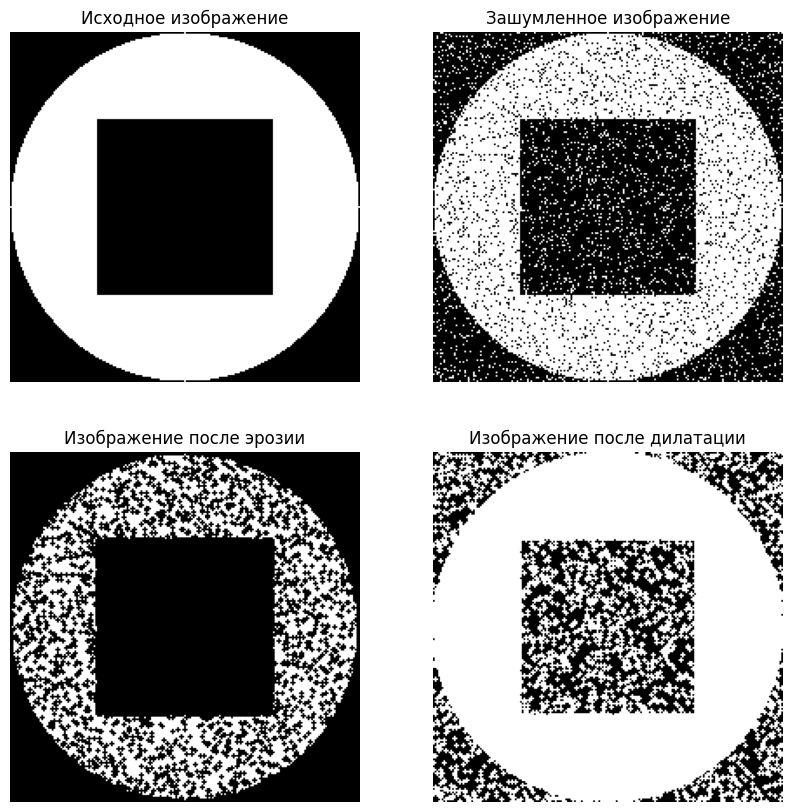

In [8]:
morth_core = np.array([[0, 1, 0], 
                       [1, 1, 1], 
                       [0, 1, 0]], dtype=np.uint8)

erosion_img = erosion(noise_img, morth_core)
delatation_img = delatation(noise_img, morth_core)

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Исходное изображение")

plt.subplot(2, 2, 2)
plt.imshow(noise_img, cmap="gray")
plt.axis("off")
plt.title("Зашумленное изображение")

plt.subplot(2, 2, 3)
plt.imshow(erosion_img, cmap="gray")
plt.axis("off")
plt.title("Изображение после эрозии")

plt.subplot(2, 2, 4)
plt.imshow(delatation_img, cmap="gray")
plt.axis("off")
plt.title("Изображение после дилатации")

plt.show()

## 5. Отфильтровать зашумленное изображение при помощи морфологических операций вскрытия и закрытия. Подсчитать коэффициент шума для результа фильтрации

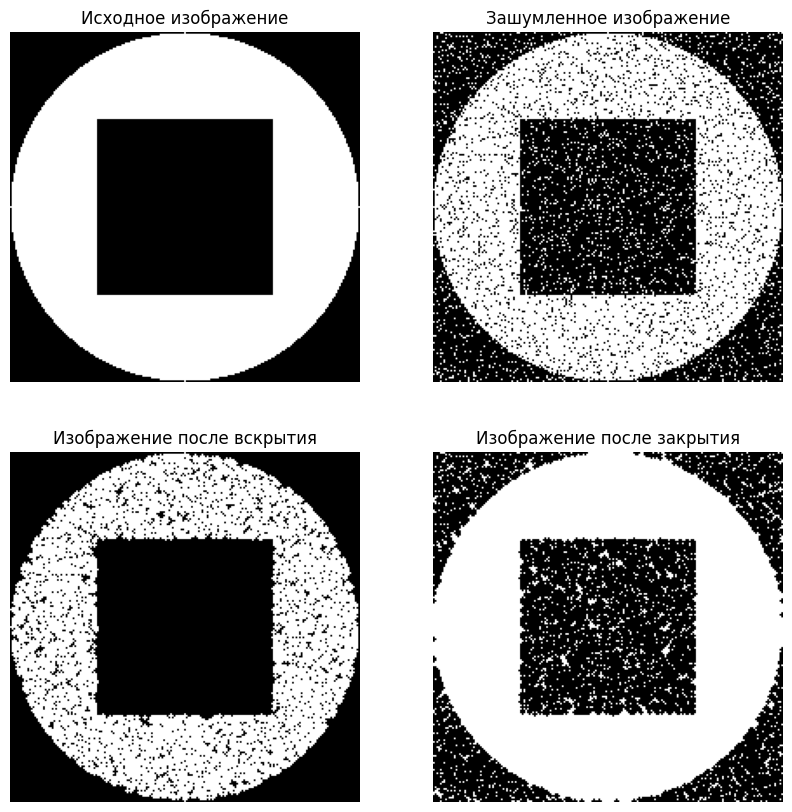

Коэффициет шума при вскрытии: 0.06695378827256751
Коэффициет шума при закрытии: 0.06544392465533032


In [9]:
opened_img = delatation(erosion_img, morth_core)
closed_img = erosion(delatation_img, morth_core)

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Исходное изображение")

plt.subplot(2, 2, 2)
plt.imshow(noise_img, cmap="gray")
plt.axis("off")
plt.title("Зашумленное изображение")

plt.subplot(2, 2, 3)
plt.imshow(opened_img, cmap="gray")
plt.axis("off")
plt.title("Изображение после вскрытия")

plt.subplot(2, 2, 4)
plt.imshow(closed_img, cmap="gray")
plt.axis("off")
plt.title("Изображение после закрытия")

plt.show()

print(f"Коэффициет шума при вскрытии: {np.sum(img != opened_img) / img.size}")
print(f"Коэффициет шума при закрытии: {np.sum(img != closed_img) / img.size}")

## 6. Отфильтровать изображение при помощи логического фильтра. Подсчитать коэффициент шума для результа фильтрации

In [10]:
def logic_core(x:np.ndarray, y:np.ndarray) -> int:
    z = (x*y).flatten()[(y != 0).flatten()]
    center_idx = z.size // 2
    z0 = z[center_idx]
    z = np.hstack([z[:center_idx], z[center_idx+1:]])
    return int((z0 & np.any(z)) | (~z0 & np.all(z)))

def logic_filter(x:np.ndarray, y:np.ndarray) -> np.ndarray:
    return slide(x, y, core=logic_core)

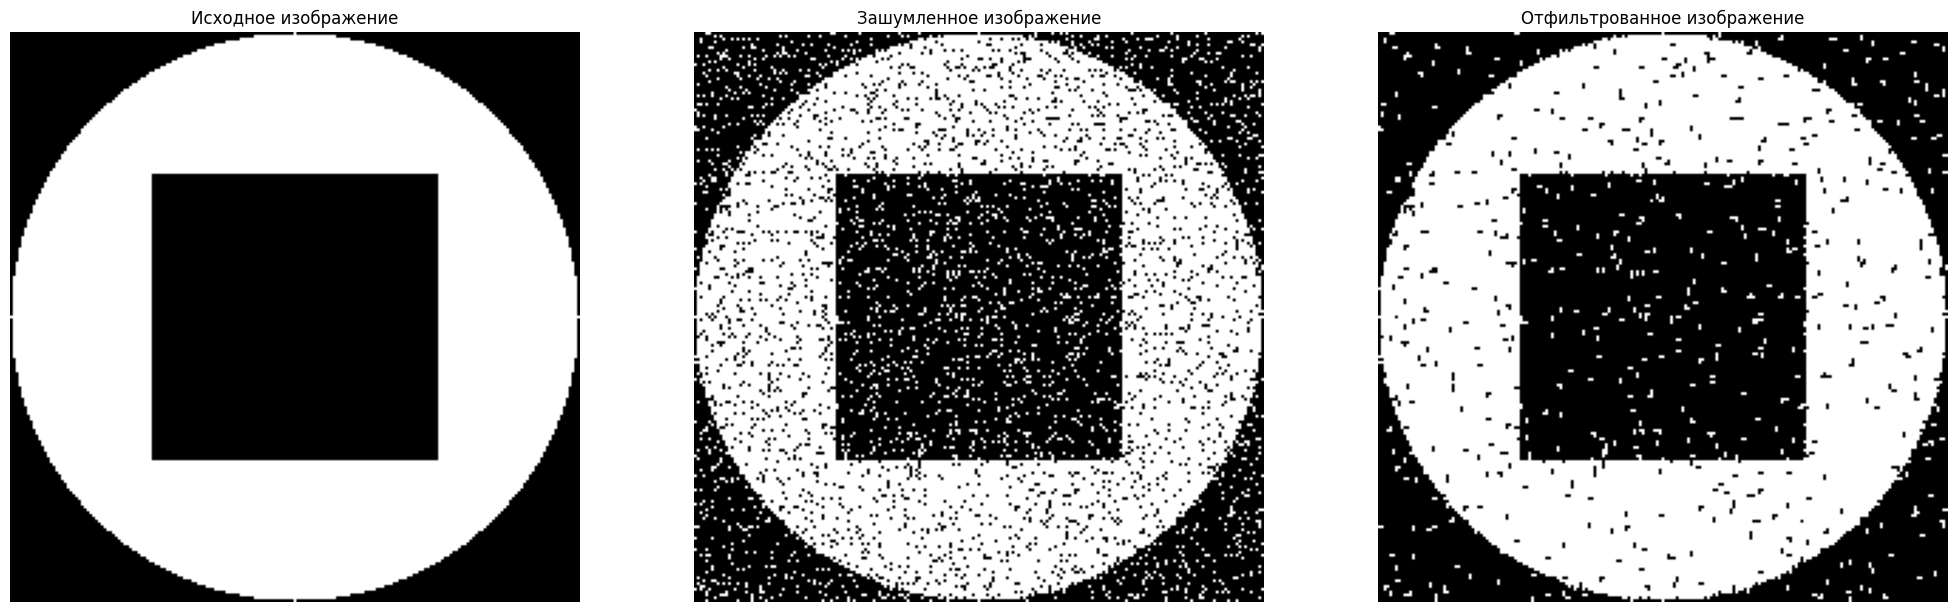

Коэффициет шума при вскрытии: 0.03569218583698423


In [11]:
logic_img = logic_filter(noise_img, morth_core)

plt.figure(figsize=(25, 15))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Исходное изображение")

plt.subplot(1, 3, 2)
plt.imshow(noise_img, cmap="gray")
plt.axis("off")
plt.title("Зашумленное изображение")

plt.subplot(1, 3, 3)
plt.imshow(logic_img, cmap="gray")
plt.axis("off")
plt.title("Отфильтрованное изображение")

plt.show()

print(f"Коэффициет шума при вскрытии: {np.sum(img != logic_img) / img.size}")

## 7. На исходном изображении с помощью морфологических операций выделить контур объекта. Выяснить, когда контур получается внешним, внутренним, четырёхсвязным, восьмисвязным

In [12]:
def mod2(x:np.ndarray, y:np.ndarray) -> np.ndarray:
    return (x + y) % 2

In [13]:
win4 = np.array([[0, 1, 0],
                 [1, 1, 1],
                 [0, 1, 0]], dtype=np.uint8)

win8 = np.array([[1, 1, 1],
                 [1, 1, 1],
                 [1, 1, 1]], dtype=np.uint8)

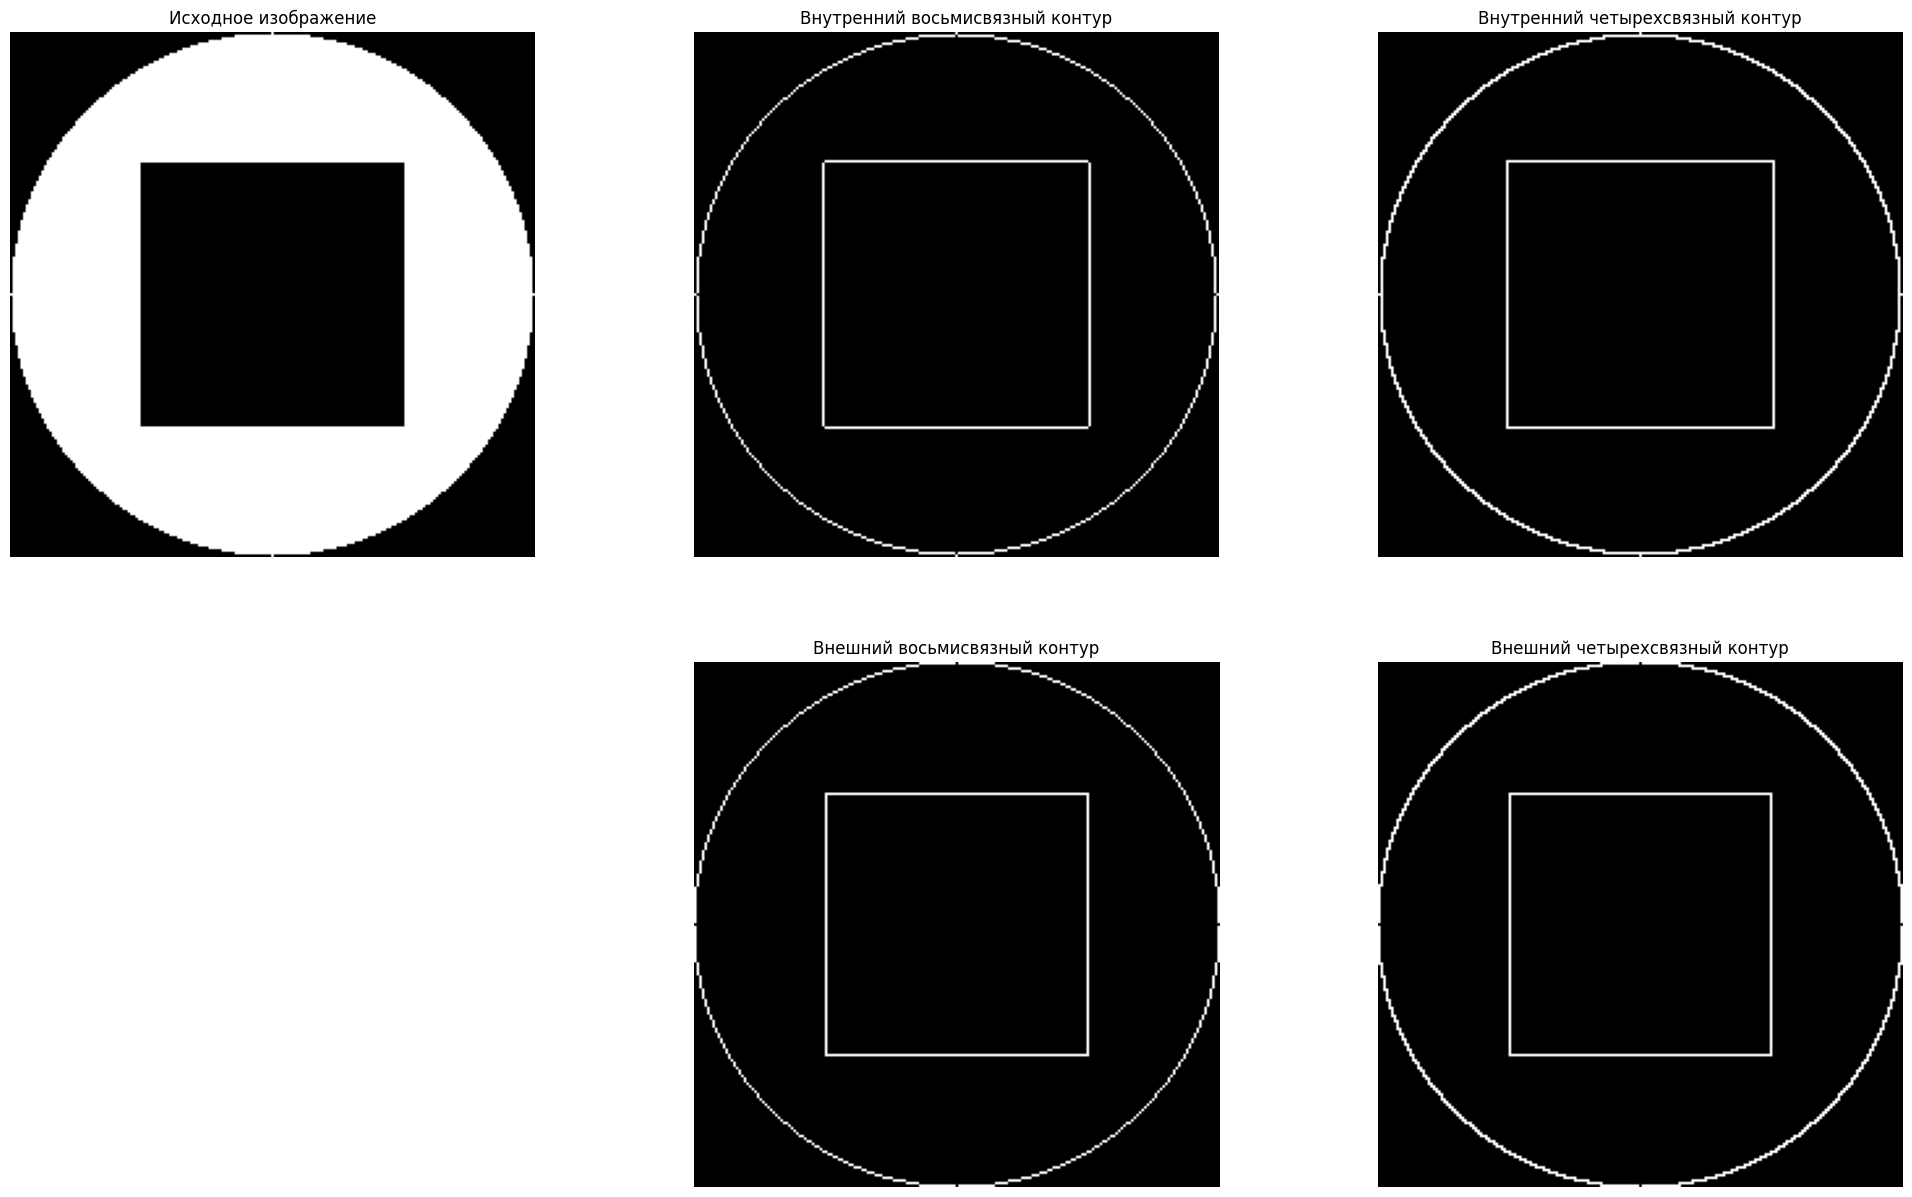

In [14]:
internal_contour_4 = mod2(img, erosion(img, win8))
internal_contour_8 = mod2(img, erosion(img, win4))
external_contour_4 = mod2(img, delatation(img, win8))
external_contour_8 = mod2(img, delatation(img, win4))

plt.figure(figsize=(25, 15))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Исходное изображение")

plt.subplot(2, 3, 2)
plt.imshow(internal_contour_8, cmap="gray")
plt.axis("off")
plt.title("Внутренний восьмисвязный контур")

plt.subplot(2, 3, 3)
plt.imshow(internal_contour_4, cmap="gray")
plt.axis("off")
plt.title("Внутренний четырехсвязный контур")

plt.subplot(2, 3, 5)
plt.imshow(external_contour_8, cmap="gray")
plt.axis("off")
plt.title("Внешний восьмисвязный контур")

plt.subplot(2, 3, 6)
plt.imshow(external_contour_4, cmap="gray")
plt.axis("off")
plt.title("Внешний четырехсвязный контур")

plt.show()

## 8. На исходном изображении с помощью морфологических операций выделить горизонтальные и вертикальные контуры объекта

In [15]:
winh = np.array([[1, 1, 1]])

winv = np.array([[1],
                 [1],
                 [1]])

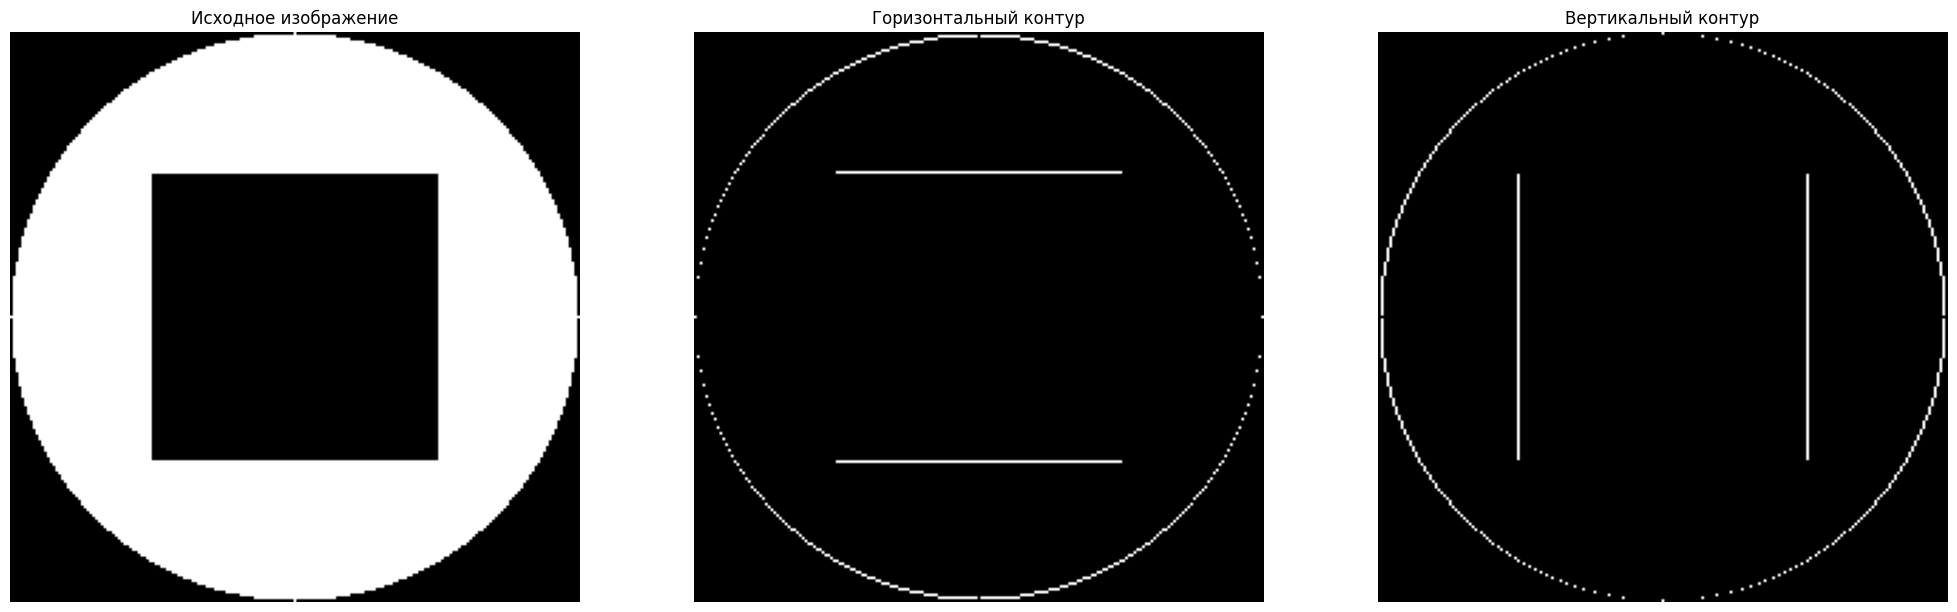

In [16]:
horizontal_contour = mod2(img, erosion(img, winv))
vertical_contour = mod2(img, erosion(img, winh))

plt.figure(figsize=(25, 15))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Исходное изображение")

plt.subplot(1, 3, 2)
plt.imshow(horizontal_contour, cmap="gray")
plt.axis("off")
plt.title("Горизонтальный контур")

plt.subplot(1, 3, 3)
plt.imshow(vertical_contour, cmap="gray")
plt.axis("off")
plt.title("Вертикальный контур")

plt.show()